[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/workshops/CANVAS_2025.ipynb)

**Open Source Pipeline to Integrate Drone and Satellite Geospatial Data Products for Agricultural Applications**

This notebook is designed for workshop presented at the [CANAVS 2025 Conference](https://www.sciencesocieties.org/canvas?q=canvas/) on November 10, 2025.

-   Registration: <https://scisoc.confex.com/scisoc/2025am/meetingapp.cgi/Session/27796>
-   Notebook: <https://opengeoai.org/workshops/CANVAS_2025>
-   Leafmap: <https://leafmap.org>
-   Samgeo: <https://samgeo.gishub.org>
-   GeoAI: <https://opengeoai.org>
-   Data to Science (D2S): <https://ps2.d2s.org>
-   D2S Python API: <https://py.d2s.org>

## Introduction

Recent advances in drone technology have revolutionized the remote sensing community by providing means to collect fine spatial and high temporal resolutions at affordable costs. As people are gaining access to increasingly larger volumes of drone and satellite geospatial data products, there is a growing need to extract relevant information from the vast amount of freely available geospatial data. However, the lack of specialized software packages tailored for processing such data makes it challenging to develop transdisciplinary research collaboration around them. This workshop aims to bridge the gap between big geospatial data and research scientists by providing training on an open-source online platform for managing big drone data known as Data to Science.

## Agenda

The main topics to be covered in this workshop include:

* Create interactive maps using leafmap
* Visualize drone imagery from D2S
* Automated segmentation of drone imagery using SAMGeo
* Training a U-Net model for tree segmentation

## Environment setup

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/workshops/CANVAS_2025.ipynb)


### Change runtime type to GPU

To speed up the processing, you can change the Colab runtime type to GPU. Go to the "Runtime" menu, select "Change runtime type", and choose "T4 GPU" from the "Hardware accelerator" dropdown menu.

![image](https://github.com/user-attachments/assets/e92d2a19-0555-456d-b4be-36680c0af09f)


### Install packages

Uncomment the following code to install the required packages.

In [1]:
%pip install -U "leafmap[raster]" "segment-geospatial[samgeo2]" geoai-py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 7.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 523.3/523.3 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 666.5/666.5 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 137.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 124.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

### Import libraries

Import the necessary libraries for this workshop.

In [2]:
import leafmap

In [3]:
from google.colab import output
output.enable_custom_widget_manager()

## Creating interactive maps

Let's create an interactive map using the `ipyleaflet` plotting backend. The [`leafmap.Map`](https://leafmap.org/leafmap/#leafmap.leafmap.m) class inherits the [`ipyleaflet.Map`](https://ipyleaflet.readthedocs.io/en/latest/map_and_basemaps/map.html) class. Therefore, you can use the same syntax to create an interactive map as you would with `ipyleaflet.Map`.

In [4]:
m = leafmap.Map()

To display it in a Jupyter notebook, simply ask for the object representation:

In [5]:
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

To customize the map, you can specify various keyword arguments, such as `center` ([lat, lon]), `zoom`, `width`, and `height`. The default `width` is `100%`, which takes up the entire cell width of the Jupyter notebook. The `height` argument accepts a number or a string. If a number is provided, it represents the height of the map in pixels. If a string is provided, the string must be in the format of a number followed by `px`, e.g., `600px`.

In [6]:
m = leafmap.Map(center=[40, -100], zoom=4, height="800px")
m

Map(center=[40, -100], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_t…

### Adding basemaps

There are several ways to add basemaps to a map. You can specify the basemap to use in the `basemap` keyword argument when creating the map. Alternatively, you can add basemap layers to the map using the `add_basemap` method. leafmap has hundreds of built-in basemaps available that can be easily added to the map with only one line of code.

Create a map by specifying the basemap to use as follows. For example, the `Esri.WorldImagery` basemap represents the Esri world imagery basemap.

In [7]:
m = leafmap.Map(basemap="Esri.WorldImagery")
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

You can add as many basemaps as you like to the map. For example, the following code adds the `OpenTopoMap` basemap to the map above:

In [8]:
m.add_basemap("OpenTopoMap")

You can also add an XYZ tile layer to the map.

In [9]:
basemap_url = "https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}"
m.add_tile_layer(basemap_url, name="Hybrid", attribution="Google")

# Connecting to Google Drive

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Download and Prepare Data for Analysis

In this section, we'll download Google Earth Imagery

In [11]:
if m.user_roi_bounds() is not None:
    bbox = m.user_roi_bounds()
else:
    bbox = [-95.3704, 29.6762, -95.368, 29.6775]
print(bbox)

[-95.3704, 29.6762, -95.368, 29.6775]


In [12]:
gdf = leafmap.bbox_to_gdf(bbox)
m.add_gdf(gdf, layer_name="AOI", info_mode=None)

In [14]:
import os
wimberley_image_path = "/content/drive/MyDrive/tms/wimberley.tif"
# Create the directory if it does not exist
os.makedirs(os.path.dirname(wimberley_image_path), exist_ok=True)
leafmap.map_tiles_to_geotiff(wimberley_image_path, bbox, zoom=18, source="Esri.WorldImagery")

Downloaded image 1/6
Downloaded image 2/6
Downloaded image 3/6
Downloaded image 4/6
Downloaded image 5/6
Downloaded image 6/6
Saving GeoTIFF. Please wait...
Image saved to /content/drive/MyDrive/tms/wimberley.tif


In [15]:
m.add_raster(wimberley_image_path, layer_name="Wimberley")
m

Map(bottom=754.0, center=[29.67685, -95.3692], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoo…

Decompressing WhiteboxTools_linux_musl.zip ...
WhiteboxTools package directory: /usr/local/lib/python3.12/dist-packages/whitebox


## Download and Prepare Data for Analysis

In this section, we'll download a subset of the drone imagery from D2S and prepare it for machine learning model training and inference.

### Define Area of Interest (AOI)

Draw an area of interest (AOI) on the map using the drawing tools, or use the default bounding box provided below. This AOI will be used to clip the imagery for analysis.

In [ ]:
# Define bounding box for the area of interest
# Format: [min_lon, min_lat, max_lon, max_lat]
if m.user_roi is not None:
    bbox = m.user_roi_bounds()  # Use drawn ROI if available
else:
    bbox = [-97.956252, 26.165315, -97.954992, 26.165883]  # Default ROI

In [ ]:
ortho_image_202206 = "ortho_image_202206.tif"
if not os.path.exists(ortho_image_202206):
    leafmap.download_file(ortho_url_202206, output=ortho_image_202206)

In [ ]:
ortho_image_202212 = "ortho_image_202212.tif"
if not os.path.exists(ortho_image_202212):
    leafmap.download_file(ortho_url_202212, output=ortho_image_202212)

Draw an area of interest (AOI) on the map. If an AOI is not provided, a default AOI will be used.

In [ ]:
if m.user_roi is not None:
    bbox = m.user_roi_bounds()
else:
    bbox = [-97.956252, 26.165315, -97.954992, 26.165883]

In [ ]:
gdf = leafmap.bbox_to_gdf(bbox)
m.add_gdf(gdf, layer_name="AOI", info_mode=None)

In [ ]:
ortho_image_10cm = "ortho_image_202206_10cm.tif"
chm_image = "chm_202206.tif"

In [ ]:
clipped_ortho_data_10cm = leafmap.clip_raster(
    ortho_image_202206,
    geometry=bbox,
    geom_crs="EPSG:4326",
    bands=[1, 2, 3],
    resolution=0.1,
    output=ortho_image_10cm,
)

In [ ]:
clipped_chm_data = leafmap.clip_raster(
    chm_url_202206,
    geometry=bbox,
    geom_crs="EPSG:4326",
    match_raster=clipped_ortho_data_10cm,
    output=chm_image,
)

In [ ]:
m = leafmap.Map()
m.add_raster(ortho_image_10cm, layer_name="Ortho Image 202206")
m.add_raster(chm_image, colormap="terrain", nodata=0, layer_name="CHM 202206")
m.add_geojson(tree_boundaries, layer_name="Tree Boundaries")
m

## Automated Segmentation with SAM (Segment Anything Model)

SAMGeo is a Python package that applies Meta's Segment Anything Model (SAM) to geospatial data. It can automatically segment objects in drone and satellite imagery without requiring training data.

### Initialize SAM2 Model

First, we'll initialize the SAM2 model with parameters that control segmentation quality and detail.

In [16]:
from samgeo import SamGeo, SamGeo2

In [17]:
# Initialize SAM2 model for automatic segmentation
sam2 = SamGeo2(
    model_id="sam2-hiera-large",  # Use the large hierarchical SAM2 model
    automatic=True,  # Enable automatic mask generation mode
    stability_score_thresh=0.9,  # Higher = fewer, more stable masks
    stability_score_offset=0.7,  # Adjusts stability calculation
)

sam2_hiera_large.pt:   0%|          | 0.00/898M [00:00<?, ?B/s]

### Generate Segmentation Masks

Run SAM2 on the ortho imagery to automatically detect and segment all objects. This process may take a few minutes depending on image size and computational resources.

In [18]:
# Generate masks for all objects detected in the image
sam2.generate(wimberley_image_path)

In [19]:
# Save the generated masks as a GeoTIFF file
# Each unique object gets a unique integer ID
sam2.save_masks(output="masks.tif")

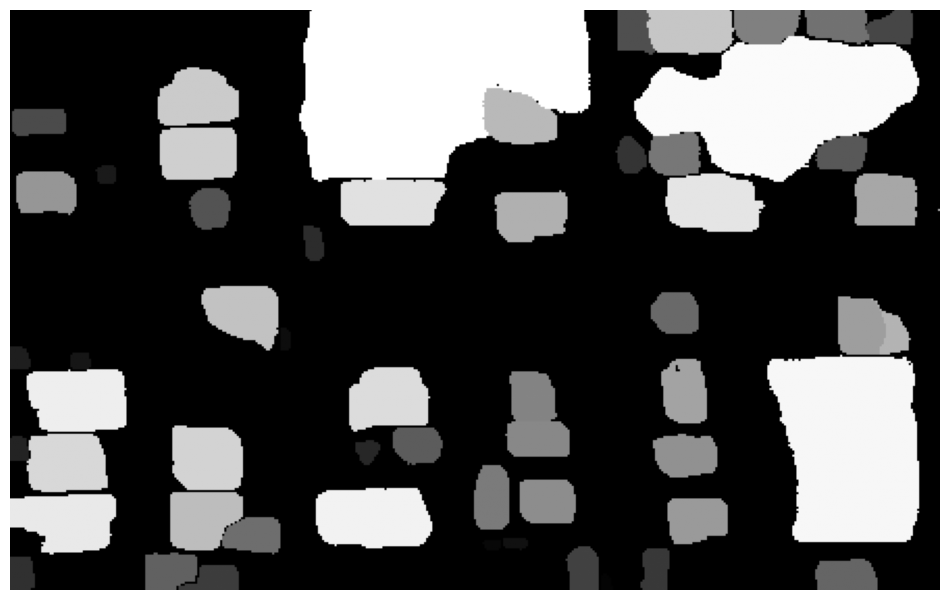

In [20]:
sam2.show_masks(cmap="binary_r")

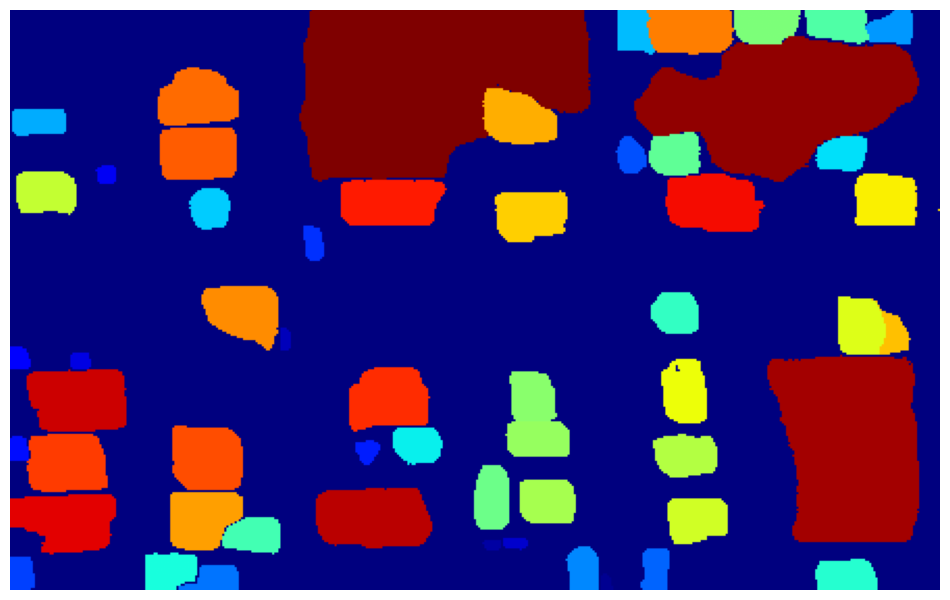

In [22]:
sam2.show_masks(cmap="jet")

Show the object annotations (objects with random color) on the map.

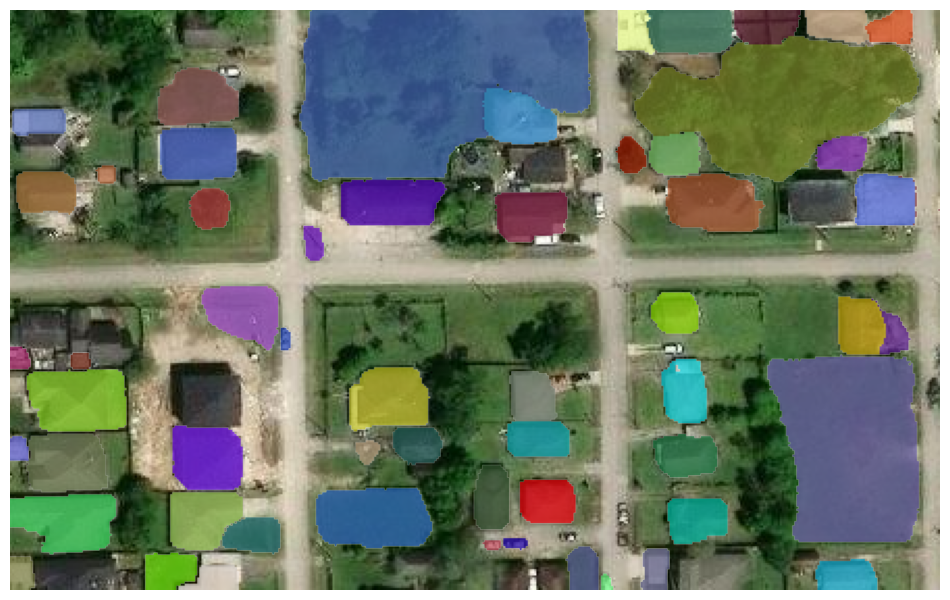

In [23]:
sam2.show_anns(axis="off", alpha=0.7, output="annotations.tif")